### Classification of Text Documents using Naive Bayes by "rishav"

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

In [96]:
df  = pd.read_csv('synthetic_text_data.csv')
df.head(10)

,text,label
0,Artificial intelligence is advancing in health...,Technology
1,Football fans are excited about the upcoming W...,Sports
2,New policies regarding climate change have spa...,Politics
3,The latest blockbuster movie has shattered box...,Entertainment
4,Quantum computing promises to revolutionize in...,Technology
5,Political debates are becoming more heated as ...,Politics
6,Tech companies are investing heavily in artifi...,Technology
7,"The summer Olympics are fast approaching, and ...",Sports
8,Music festivals are back this year with global...,Entertainment
9,The rise of self-driving cars is changing the ...,Technology


In [88]:
x = df['text']
y = df['label']

In [89]:
x_train , x_test , y_train , y_test = train_test_split(x,y, test_size = 0.2 , random_state = 42)

vec = CountVectorizer(strip_accents=None , lowercase=True , stop_words = 'english')
x_train_v = vec.fit_transform(x_train)
x_test_v = vec.transform(x_test)

model = MultinomialNB()
model.fit(x_train_v , y_train)

y_Pre  = model.predict(x_test_v)



In [90]:
print("The accuracy of the model is : ",accuracy_score(y_test , y_pre)*100)
print(confusion_matrix(y_test , y_pre))

The accuracy of the model is :  88.23529411764706
[[2 0 0 0]
 [0 5 0 0]
 [0 0 2 1]
 [1 0 0 6]]


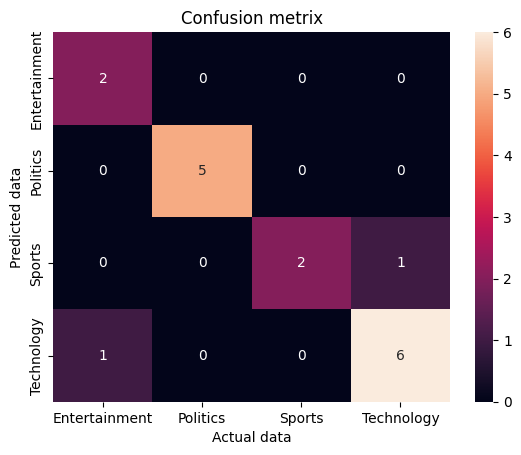

In [91]:
import numpy as np
import seaborn as sns
class_labels = np.unique(y_test)
sns.heatmap(confusion_matrix(y_test , y_pre) , annot=True , fmt = 'd' , xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Actual data')
plt.ylabel('Predicted data')
plt.title('Confusion metrix')
plt.show()

## TEST ON UNSEEN DATA

In [95]:
user_input = ("focusing")
if user_input == "":
    print("write your word to predict")
else:
    user_input_vec = vec.transform([user_input])
    user_pre = model.predict(user_input_vec) 
    print(f"The user input belong to '{user_pre[0]}' categories")

The user input belong to 'Entertainment' categories
